<a href="https://colab.research.google.com/github/yoloaryan/Predicting_emotions_of_text/blob/main/Predictiong_emotions_of_text.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Emotion Classification with RNNs, LSTM's & GRUs**

Classifying text into 6 emotions(sadness,joy,love,anger,fear, surprise )by comparing plain recurrent models before nuilding an Advancement Bidirectional GRU

# 1.Import Libraries


In [31]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#dataset load karwane mai help karofe
from datasets import load_dataset


# 2. Load Dataset

In [32]:
emotion_dataset = load_dataset('dair-ai/emotion')

emotion_dataset['train']['text']

Column(['i didnt feel humiliated', 'i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake', 'im grabbing a minute to post i feel greedy wrong', 'i am ever feeling nostalgic about the fireplace i will know that it is still on the property', 'i am feeling grouchy'])

In [33]:
emotion_dataset['train']['text']
train_text = emotion_dataset['train']['text']
train_label = emotion_dataset['train']['label']
train_label

test_text = emotion_dataset['test']['text']
test_label = emotion_dataset['test']['label']


In [34]:
label_names =emotion_dataset['train'].features['label'].names

In [35]:
label_names

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

In [36]:
#mapping o fthe data , assigning the values to the  assigned emotions in the form such as   0 -> sadness for refrencde
for i in train_label:
  print(label_names[i]) # label_names[3]]

Streaming output truncated to the last 5000 lines.
sadness
sadness
anger
fear
love
joy
anger
sadness
sadness
joy
fear
joy
fear
love
love
anger
anger
sadness
fear
sadness
sadness
surprise
love
joy
joy
love
sadness
joy
joy
fear
sadness
anger
anger
sadness
love
fear
fear
anger
anger
joy
sadness
sadness
joy
joy
fear
sadness
joy
love
fear
anger
sadness
joy
anger
surprise
fear
joy
joy
love
fear
sadness
joy
anger
fear
anger
sadness
sadness
sadness
anger
sadness
fear
joy
anger
anger
sadness
fear
joy
anger
fear
sadness
joy
fear
joy
love
anger
fear
fear
fear
fear
joy
anger
anger
sadness
joy
sadness
joy
sadness
sadness
joy
sadness
fear
fear
joy
sadness
joy
sadness
joy
fear
anger
sadness
joy
anger
joy
joy
sadness
joy
joy
anger
anger
joy
joy
joy
sadness
joy
joy
joy
anger
anger
joy
love
joy
love
joy
joy
joy
sadness
joy
sadness
surprise
sadness
anger
anger
anger
fear
fear
joy
fear
fear
joy
anger
joy
joy
joy
love
joy
fear
sadness
sadness
surprise
sadness
sadness
anger
joy
love
fear
joy
anger
joy
surpr

In [37]:
df_train = pd.DataFrame(
    {
        'text':train_text,
        'label':[label_names[i] for i in train_label]
    }
)
df_test = pd.DataFrame(
    {
        'text': test_text,
        'label':[label_names[i] for i  in test_label]
    }
)

In [38]:
df_train.head()

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [39]:
df_test.head()

,text,label
0,im feeling rather rotten so im not very ambiti...,sadness
1,im updating my blog because i feel shitty,sadness
2,i never make her separate from me because i do...,sadness
3,i left with my bouquet of red and yellow tulip...,joy
4,i was feeling a little vain when i did this one,sadness


# **3. Exploratory Data Analysis (EDA)**

Visualize class distribution across the 6 emotion labels.

In [40]:
df_train['label'].value_counts()

,count
label,
joy,5362
sadness,4666
anger,2159
fear,1937
love,1304
surprise,572


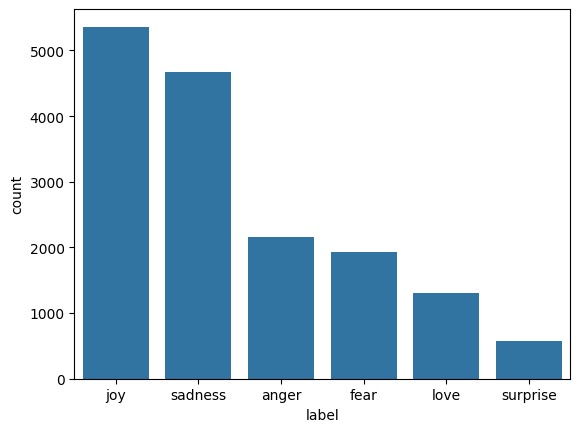

In [41]:
sns.countplot(x='label',data=df_train,order=df_train['label'].value_counts().index)
plt.show()

In [42]:
df_train

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger
...,...,...
15995,i just had a very brief time in the beanbag an...,sadness
15996,i am now turning and i feel pathetic that i am...,sadness
15997,i feel strong and good overall,joy
15998,i feel like this was such a rude comment and i...,anger


# **4. Data Preprocessing - Using NLP**

Tokenize text, pad sequences to max length 50, and convert labels to NumPy arrays.

In [43]:
#oov_token ='unkn' meaning the text which is not trained in the  training set but if the the words appears in the test case it will show the the oout of vocab options
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
max_words =10000

tokenizer=Tokenizer(num_words= max_words,oov_token='<unk>')
tokenizer.fit_on_texts(df_train['text'])

train_sequence = tokenizer.texts_to_sequences(df_train['text'])
test_sequence = tokenizer.texts_to_sequences(df_test['text'])

train_sequence # words are now converted into the text



[[2, 139, 3, 679],
 [2,
  40,
  101,
  60,
  8,
  15,
  494,
  5,
  15,
  3496,
  553,
  32,
  60,
  61,
  128,
  148,
  76,
  1480,
  4,
  22,
  1255],
 [17, 3060, 7, 1149, 5, 286, 2, 3, 495, 438],
 [2, 24, 165, 8, 665, 27, 6, 4158, 2, 59, 47, 9, 13, 22, 72, 30, 6, 3497],
 [2, 24, 8, 1065],
 [73, 48, 8, 7, 56, 521, 319, 328, 158, 161, 9, 20],
 [73,
  48,
  329,
  35,
  7401,
  35,
  196,
  7402,
  888,
  4,
  73,
  2475,
  1384,
  7,
  159,
  1885,
  19,
  2,
  117,
  3,
  14,
  15,
  455],
 [2, 3, 29, 439, 27, 78, 29, 7, 1686, 35, 29, 760, 29, 7, 193, 267, 374],
 [2,
  21,
  48,
  25,
  5260,
  16,
  215,
  2,
  3,
  9,
  5260,
  99,
  5261,
  135,
  4,
  132,
  7,
  1038,
  4159],
 [2, 3, 666, 94],
 [2, 3, 14, 2, 21, 5, 80, 6, 733, 2, 93, 544, 304, 84],
 [2,
  39,
  3,
  9,
  483,
  22,
  7,
  530,
  440,
  4,
  9,
  2,
  40,
  920,
  5,
  21,
  69,
  840,
  10,
  1886,
  3061],
 [2, 70, 13, 90, 6, 5262, 52, 10, 193, 5, 3, 610],
 [2, 3, 339, 456, 2, 93, 32, 4160],
 [2,
  21,
  4161,

In [44]:
padded_train_sequence= pad_sequences(train_sequence,maxlen=50,padding='post',truncating='post')
padded_test_sequence= pad_sequences(test_sequence,maxlen=50,padding='post',truncating='post')


padded_train_sequence

array([[   2,  139,    3, ...,    0,    0,    0],
       [   2,   40,  101, ...,    0,    0,    0],
       [  17, 3060,    7, ...,    0,    0,    0],
       ...,
       [   2,    3,  327, ...,    0,    0,    0],
       [   2,    3,   14, ...,    0,    0,    0],
       [   2,   47,    7, ...,    0,    0,    0]], dtype=int32)

In [45]:
train_label = np.array(train_label)
test_label = np.array(test_label)

In [46]:
train_label

array([0, 0, 3, ..., 1, 3, 0])

In [47]:
test_label

array([0, 0, 0, ..., 1, 1, 4])

In [48]:
num_classes = len(np.unique(train_label))
num_classes

6

In [49]:
print(f"Vocabluary Size: {len(tokenizer.word_index)}")
print(f"Max Sentence Length : {padded_train_sequence.shape[1]}")

Vocabluary Size: 15213
Max Sentence Length : 50


# **5. Shared Training Utilities**

Compute balanced class weights to handle dataset skew and setup early stopping.

In [50]:
from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight(
    class_weight ='balanced',
    classes      = np.unique(train_label),
    y = train_label
)
class_weight_dict=dict(enumerate(class_weights))


In [51]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor = 'val_loss',
    patience = 3,
    restore_best_weights = True
)


# **6. Phase 1 — Plain Foundational Models**

Train plain (non-bidirectional) Simple RNN, Standard LSTM, and Standard GRU models.

# **6.1 Model 1 — Simple RNN**

Plain unrolled Recurrent Neural Network.